# 🛒 Superstore Sales Analysis using SQL & Python
### A Data Analytics Project — SQL + Visualization

**Author:** [Preeti Bhardwaj]  
**Domain:** Retail / E-Commerce  
**Dataset:** Sample Superstore — 9,994 orders, US Retail Store (2014–2017)  
**Source:** [Kaggle — Vivek468](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)  
**Tools:** Python, SQLite, pandas, matplotlib, seaborn

---

## 🎯 Project Objective
A US-based retail superstore wants to understand its sales performance, identify profitable and loss-making products, and find actionable opportunities to increase profitability.

As a data analyst, I used **SQL queries** to answer 12 key business questions and **Python visualizations** to present the findings clearly to stakeholders.

## 📋 Business Questions Answererd
1. What is the overall business performance? (Revenue, Profit, Orders)
2. Which region generates the most sales and profit?
3. Which product categories are most and least profitable?
4. Who are our top customers — and are they actually profitable?
5. Which sub-categories are losing money?
6. How has the business grown year over year?
7. Which customer segments are most valuable?
8. Which states are performing well vs poorly?
9. How do discounts affect profitability?
10. What shipping mode do most customers prefer?
11. Which sub-categories have the best/worst profit margins?
12. Who are the top customers within each segment? *(Window Function)*




---
## 📦 Section 1: Setup & Data Loading

In [ ]:
# Import all required libraries
import pandas as pd        # data manipulation
import numpy as np         # numerical operations
import matplotlib.pyplot as plt  # visualizations
import seaborn as sns      # beautiful charts
import sqlite3             # SQL database engine
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print("All libraries loaded ✅")

All libraries loaded ✅


In [ ]:
# Upload and extract dataset
from google.colab import files
import zipfile, os

uploaded = files.upload()  # upload archive.zip

with zipfile.ZipFile('sales.zip', 'r') as zip_ref:
    zip_ref.extractall('superstore_data')

print("Files found:", os.listdir('superstore_data'))

Saving sales.zip to sales (1).zip
Files found: ['Sample - Superstore.csv']


In [ ]:
# Load CSV into pandas DataFrame
# encoding='latin-1' handles special characters in product names
df = pd.read_csv('superstore_data/Sample - Superstore.csv', encoding='latin-1')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")
print(f"\nFirst look at the data:")
df.head()

Dataset shape: 9994 rows, 21 columns
Date range: 1/1/2017 to 9/9/2017

First look at the data:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### 📋 Dataset Overview

| Column | Type | Description |
|--------|------|-------------|
| Order ID | Text | Unique order identifier |
| Order Date | Date | When the order was placed |
| Ship Mode | Text | Shipping method chosen |
| Customer ID/Name | Text | Customer identifier |
| Segment | Text | Customer type: Consumer, Corporate, Home Office |
| Region/State/City | Text | Location information |
| Category/Sub-Category | Text | Product classification |
| Product Name | Text | Name of product |
| Sales | Number | Revenue from the order |
| Quantity | Number | Units ordered |
| Discount | Number | Discount applied (0–1 scale) |
| Profit | Number | Profit earned (can be negative!) |


In [ ]:
# Create SQLite database and load data
# SQLite is a lightweight SQL database that runs inside Python
# In production, this would be MySQL, PostgreSQL, or SQL Server

conn = sqlite3.connect('superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

print("✅ SQLite database created: superstore.db")
print(f"✅ Table 'orders' loaded with {len(df):,} rows")
print("\nWe can now run SQL queries on this data!")

✅ SQLite database created: superstore.db
✅ Table 'orders' loaded with 9,994 rows

We can now run SQL queries on this data!


In [ ]:
# Helper function to run SQL queries and display results cleanly
# This makes it easy to run any SQL query with just one line
def run_query(query, description=""):
    result = pd.read_sql_query(query, conn)
    if description:
        print(f"\n{'='*55}")
        print(f"  📊 {description}")
        print(f"{'='*55}")
    print(result.to_string(index=False))
    return result

print("Helper function ready ✅")
print("Usage: run_query('SELECT ...', 'Description')")

Helper function ready ✅
Usage: run_query('SELECT ...', 'Description')


---
## 🗄️ Section 2: SQL Business Analysis

### SQL Concepts Used in This Project
| Concept | Queries |
|---------|---------|
| `SELECT`, `FROM`, `WHERE` | All queries |
| `GROUP BY`, `ORDER BY` | Q2–Q12 |
| `SUM`, `COUNT`, `AVG`, `ROUND` | All aggregations |
| `DISTINCT` | Counting unique orders/customers |
| `LIMIT` | Top N results |
| `CASE WHEN` | Creating categories (discount ranges) |
| `WITH` (CTE) | Query 12 — Window functions |
| `RANK() OVER (PARTITION BY)` | Query 12 — Ranking within groups |


### Query 1 — Overall Business Performance

In [ ]:
# SQL Concepts: SELECT, SUM, COUNT, DISTINCT, AVG, ROUND
# Business Question: What is the overall health of our business?

run_query("""
    SELECT
        ROUND(SUM(Sales), 2)            AS Total_Revenue,
        ROUND(SUM(Profit), 2)           AS Total_Profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 1) AS Profit_Margin_Pct,
        COUNT(DISTINCT "Order ID")      AS Total_Orders,
        COUNT(DISTINCT "Customer ID")   AS Total_Customers,
        ROUND(AVG(Sales), 2)            AS Avg_Order_Value
    FROM orders
""", "Overall Business Summary")


  📊 Overall Business Summary
 Total_Revenue  Total_Profit  Profit_Margin_Pct  Total_Orders  Total_Customers  Avg_Order_Value
    2297200.86     286397.02               12.5          5009              793           229.86


,Total_Revenue,Total_Profit,Profit_Margin_Pct,Total_Orders,Total_Customers,Avg_Order_Value
0,2297200.86,286397.02,12.5,5009,793,229.86


**💡 Key Findings:**
- Total Revenue: **$2.29 Million** across 4 years
- Overall Profit Margin: **12.5%** — reasonable for retail
- 5,009 orders from 793 unique customers
- Average order value: **$229.86**

### Query 2 — Sales & Profit by Region

In [ ]:
# SQL Concepts: GROUP BY, ORDER BY, SUM, COUNT DISTINCT
# Business Question: Which region is most valuable?

run_query("""
    SELECT
        Region,
        ROUND(SUM(Sales), 2)             AS Total_Sales,
        ROUND(SUM(Profit), 2)            AS Total_Profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 1) AS Profit_Margin_Pct,
        COUNT(DISTINCT "Order ID")       AS Total_Orders
    FROM orders
    GROUP BY Region
    ORDER BY Total_Sales DESC
""", "Sales & Profit by Region")


  📊 Sales & Profit by Region
 Region  Total_Sales  Total_Profit  Profit_Margin_Pct  Total_Orders
   West    725457.82     108418.45               14.9          1611
   East    678781.24      91522.78               13.5          1401
Central    501239.89      39706.36                7.9          1175
  South    391721.91      46749.43               11.9           822


,Region,Total_Sales,Total_Profit,Profit_Margin_Pct,Total_Orders
0,West,725457.82,108418.45,14.9,1611
1,East,678781.24,91522.78,13.5,1401
2,Central,501239.89,39706.36,7.9,1175
3,South,391721.91,46749.43,11.9,822


**💡 Key Findings:**
- **West leads** with $725K sales and best profit margins
- **Central has a problem** — $501K in sales but only 7.9% profit margin vs West's 14.9%
- South has lowest sales AND lowest orders — needs attention
- **Business action:** Investigate why Central has poor margins despite decent sales

### Query 3 — Sales by Product Category

In [ ]:
# SQL Concepts: GROUP BY, AVG, multiple aggregations
# Business Question: Which product category is most profitable?

run_query("""
    SELECT
        Category,
        ROUND(SUM(Sales), 2)         AS Total_Sales,
        ROUND(SUM(Profit), 2)        AS Total_Profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 1) AS Profit_Margin_Pct,
        ROUND(AVG(Discount)*100, 1)  AS Avg_Discount_Pct,
        SUM(Quantity)                AS Total_Units_Sold
    FROM orders
    GROUP BY Category
    ORDER BY Total_Sales DESC
""", "Sales by Product Category")


  📊 Sales by Product Category
       Category  Total_Sales  Total_Profit  Profit_Margin_Pct  Avg_Discount_Pct  Total_Units_Sold
     Technology    836154.03     145454.95               17.4              13.2              6939
      Furniture    741999.80      18451.27                2.5              17.4              8028
Office Supplies    719047.03     122490.80               17.0              15.7             22906


,Category,Total_Sales,Total_Profit,Profit_Margin_Pct,Avg_Discount_Pct,Total_Units_Sold
0,Technology,836154.03,145454.95,17.4,13.2,6939
1,Furniture,741999.80,18451.27,2.5,17.4,8028
2,Office Supplies,719047.03,122490.80,17.0,15.7,22906


**💡 Key Findings:**
- **Technology = highest sales ($836K) AND highest profit ($145K)**
- **Furniture = high sales ($742K) but terrible profit ($18K)** — only 2.5% margin!
- **Office Supplies = most units sold (22,906)** but mid-range profit
- High Furniture discounts (17.4%) are clearly destroying its profitability

### Query 4 — Top 10 Customers by Revenue

In [ ]:
# SQL Concepts: GROUP BY multiple columns, ORDER BY, LIMIT
# Business Question: Who are our biggest customers — and are they profitable?

run_query("""
    SELECT
        "Customer Name",
        Segment,
        Region,
        ROUND(SUM(Sales), 2)           AS Total_Spent,
        ROUND(SUM(Profit), 2)          AS Profit_Generated,
        COUNT(DISTINCT "Order ID")     AS Total_Orders
    FROM orders
    GROUP BY "Customer ID", "Customer Name", Segment, Region
    ORDER BY Total_Spent DESC
    LIMIT 10
""", "Top 10 Customers by Revenue")


  📊 Top 10 Customers by Revenue
Customer Name     Segment  Region  Total_Spent  Profit_Generated  Total_Orders
  Sean Miller Home Office   South     23669.20          -1787.04             2
 Tamara Chand   Corporate Central     18437.14           8745.06             2
 Raymond Buch    Consumer    West     14345.28           6807.09             2
 Tom Ashbrook Home Office    East     13723.50           4599.21             2
Adrian Barton    Consumer Central     12181.59           5362.61             5
 Becky Martin    Consumer Central     10539.90          -1878.79             1
 Hunter Lopez    Consumer    East     10522.55           5045.86             2
 Bill Shonely   Corporate    East     10022.29           2558.58             2
 Sanjit Chand    Consumer Central      9900.19           4668.69             1
    Greg Tran    Consumer    East      9382.93           1749.11             5


,Customer Name,Segment,Region,Total_Spent,Profit_Generated,Total_Orders
0,Sean Miller,Home Office,South,23669.20,-1787.04,2
1,Tamara Chand,Corporate,Central,18437.14,8745.06,2
2,Raymond Buch,Consumer,West,14345.28,6807.09,2
3,Tom Ashbrook,Home Office,East,13723.50,4599.21,2
4,Adrian Barton,Consumer,Central,12181.59,5362.61,5
5,Becky Martin,Consumer,Central,10539.90,-1878.79,1
6,Hunter Lopez,Consumer,East,10522.55,5045.86,2
7,Bill Shonely,Corporate,East,10022.29,2558.58,2
8,Sanjit Chand,Consumer,Central,9900.19,4668.69,1
9,Greg Tran,Consumer,East,9382.93,1749.11,5


**💡 Key Findings — Surprising!**
- **Sean Miller (#1 by revenue) is LOSING us $1,787!** — $23K spent but negative profit
- **Becky Martin ($10.5K revenue) losing $1,879** — should be flagged for review
- **Tamara Chand** is the most valuable customer — high revenue AND high profit
- **Lesson:** Revenue ≠ Profit. Top spending customers are not always profitable!

### Query 5 — Most Profitable Sub-Categories

In [ ]:
# SQL Concepts: GROUP BY two columns, calculated profit margin
# Business Question: Which specific products make us the most money?

run_query("""
    SELECT
        Category,
        "Sub-Category",
        ROUND(SUM(Sales), 2)                  AS Total_Sales,
        ROUND(SUM(Profit), 2)                 AS Total_Profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 1)  AS Profit_Margin_Pct
    FROM orders
    GROUP BY Category, "Sub-Category"
    ORDER BY Total_Profit DESC
    LIMIT 10
""", "Top 10 Most Profitable Sub-Categories")


  📊 Top 10 Most Profitable Sub-Categories
       Category Sub-Category  Total_Sales  Total_Profit  Profit_Margin_Pct
     Technology      Copiers    149528.03      55617.82               37.2
     Technology       Phones    330007.05      44515.73               13.5
     Technology  Accessories    167380.32      41936.64               25.1
Office Supplies        Paper     78479.21      34053.57               43.4
Office Supplies      Binders    203412.73      30221.76               14.9
      Furniture       Chairs    328449.10      26590.17                8.1
Office Supplies      Storage    223843.61      21278.83                9.5
Office Supplies   Appliances    107532.16      18138.01               16.9
      Furniture  Furnishings     91705.16      13059.14               14.2
Office Supplies    Envelopes     16476.40       6964.18               42.3


,Category,Sub-Category,Total_Sales,Total_Profit,Profit_Margin_Pct
0,Technology,Copiers,149528.03,55617.82,37.2
1,Technology,Phones,330007.05,44515.73,13.5
2,Technology,Accessories,167380.32,41936.64,25.1
3,Office Supplies,Paper,78479.21,34053.57,43.4
4,Office Supplies,Binders,203412.73,30221.76,14.9
5,Furniture,Chairs,328449.10,26590.17,8.1
6,Office Supplies,Storage,223843.61,21278.83,9.5
7,Office Supplies,Appliances,107532.16,18138.01,16.9
8,Furniture,Furnishings,91705.16,13059.14,14.2
9,Office Supplies,Envelopes,16476.40,6964.18,42.3


**💡 Key Findings:**
- **Copiers** = highest profit ($55K) with 37.2% margin — premium product!
- **Paper** = 43.4% profit margin — cheapest product but most efficient!
- **Phones & Accessories** dominate technology profitability
- Top 3 profitable sub-categories are all Technology

### Query 6 — Loss Making Sub-Categories

In [ ]:
# Business Question: Which products are COSTING us money?
# This is critical — high sales doesn't mean high profit!

run_query("""
    SELECT
        Category,
        "Sub-Category",
        ROUND(SUM(Sales), 2)                 AS Total_Sales,
        ROUND(SUM(Profit), 2)                AS Total_Profit,
        ROUND(AVG(Discount)*100, 1)          AS Avg_Discount_Pct
    FROM orders
    GROUP BY Category, "Sub-Category"
    HAVING Total_Profit < 0
    ORDER BY Total_Profit ASC
""", "Loss Making Sub-Categories")


  📊 Loss Making Sub-Categories
       Category Sub-Category  Total_Sales  Total_Profit  Avg_Discount_Pct
      Furniture       Tables    206965.53     -17725.48              26.1
      Furniture    Bookcases    114880.00      -3472.56              21.1
Office Supplies     Supplies     46673.54      -1189.10               7.7


,Category,Sub-Category,Total_Sales,Total_Profit,Avg_Discount_Pct
0,Furniture,Tables,206965.53,-17725.48,26.1
1,Furniture,Bookcases,114880.00,-3472.56,21.1
2,Office Supplies,Supplies,46673.54,-1189.10,7.7


**💡 Key Findings:**
- **Tables** — $207K in sales but **-$17,725 loss!** 26% average discount is destroying profits
- **Bookcases** — $115K in sales but **-$3,472 loss!**
- **Clear pattern:** High discounts = losses. All loss-making products have high average discounts
- **Business action:** Cap discounts on Tables and Bookcases at maximum 15%

### Query 7 — Year over Year Sales Growth

In [ ]:
# SQL Concepts: SUBSTR to extract year from date string
# Business Question: Is the business growing year over year?

run_query("""
    SELECT
        SUBSTR("Order Date", -4)         AS Year,
        ROUND(SUM(Sales), 2)             AS Total_Sales,
        ROUND(SUM(Profit), 2)            AS Total_Profit,
        ROUND(SUM(Profit)/SUM(Sales)*100,1) AS Profit_Margin_Pct,
        COUNT(DISTINCT "Order ID")       AS Total_Orders
    FROM orders
    GROUP BY Year
    ORDER BY Year
""", "Year over Year Business Growth")


  📊 Year over Year Business Growth
Year  Total_Sales  Total_Profit  Profit_Margin_Pct  Total_Orders
2014    484247.50      49543.97               10.2           969
2015    470532.51      61618.60               13.1          1038
2016    609205.60      81795.17               13.4          1315
2017    733215.26      93439.27               12.7          1687


,Year,Total_Sales,Total_Profit,Profit_Margin_Pct,Total_Orders
0,2014,484247.50,49543.97,10.2,969
1,2015,470532.51,61618.60,13.1,1038
2,2016,609205.60,81795.17,13.4,1315
3,2017,733215.26,93439.27,12.7,1687


**💡 Key Findings:**
- **Revenue grew every single year** — from $484K (2014) to $733K (2017) = **51% growth!**
- **Profit also grew consistently** — $49K to $93K = **88% profit growth!**
- 2016–2017 showed the strongest growth — 1,315 to 1,687 orders
- **Business is healthy and growing** — positive trend across all metrics

### Query 8 — Customer Segment Analysis

In [ ]:
# Business Question: Which customer type is most valuable?
# Segments: Consumer, Corporate, Home Office

run_query("""
    SELECT
        Segment,
        COUNT(DISTINCT "Customer ID")   AS Total_Customers,
        ROUND(SUM(Sales), 2)            AS Total_Sales,
        ROUND(SUM(Profit), 2)           AS Total_Profit,
        ROUND(AVG(Sales), 2)            AS Avg_Order_Value,
        ROUND(SUM(Profit)/SUM(Sales)*100,1) AS Profit_Margin_Pct
    FROM orders
    GROUP BY Segment
    ORDER BY Total_Sales DESC
""", "Sales by Customer Segment")


  📊 Sales by Customer Segment
    Segment  Total_Customers  Total_Sales  Total_Profit  Avg_Order_Value  Profit_Margin_Pct
   Consumer              409   1161401.34     134119.21           223.73               11.5
  Corporate              236    706146.37      91979.13           233.82               13.0
Home Office              148    429653.15      60298.68           240.97               14.0


,Segment,Total_Customers,Total_Sales,Total_Profit,Avg_Order_Value,Profit_Margin_Pct
0,Consumer,409,1161401.34,134119.21,223.73,11.5
1,Corporate,236,706146.37,91979.13,233.82,13.0
2,Home Office,148,429653.15,60298.68,240.97,14.0


**💡 Key Findings:**
- **Consumer segment = largest** — 409 customers, $1.16M in sales
- **Home Office = highest avg order value** ($241) and best profit margin (14%)
- **Corporate** — middle ground but strong profit ($92K)
- **Business action:** Target Home Office customers for premium product upselling

### Query 9 — Top 10 States by Sales

In [ ]:
# Business Question: Which states are our best and worst performers?

run_query("""
    SELECT
        State,
        Region,
        ROUND(SUM(Sales), 2)                  AS Total_Sales,
        ROUND(SUM(Profit), 2)                 AS Total_Profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 1)  AS Profit_Margin_Pct,
        COUNT(DISTINCT "Order ID")            AS Orders
    FROM orders
    GROUP BY State, Region
    ORDER BY Total_Sales DESC
    LIMIT 10
""", "Top 10 States by Sales")


  📊 Top 10 States by Sales
       State  Region  Total_Sales  Total_Profit  Profit_Margin_Pct  Orders
  California    West    457687.63      76381.39               16.7    1021
    New York    East    310876.27      74038.55               23.8     562
       Texas Central    170188.05     -25729.36              -15.1     487
  Washington    West    138641.27      33402.65               24.1     256
Pennsylvania    East    116511.91     -15559.96              -13.4     288
     Florida   South     89473.71      -3399.30               -3.8     200
    Illinois Central     80166.10     -12607.89              -15.7     276
        Ohio    East     78258.14     -16971.38              -21.7     236
    Michigan Central     76269.61      24463.19               32.1     117
    Virginia   South     70636.72      18597.95               26.3     115


,State,Region,Total_Sales,Total_Profit,Profit_Margin_Pct,Orders
0,California,West,457687.63,76381.39,16.7,1021
1,New York,East,310876.27,74038.55,23.8,562
2,Texas,Central,170188.05,-25729.36,-15.1,487
3,Washington,West,138641.27,33402.65,24.1,256
4,Pennsylvania,East,116511.91,-15559.96,-13.4,288
5,Florida,South,89473.71,-3399.30,-3.8,200
6,Illinois,Central,80166.10,-12607.89,-15.7,276
7,Ohio,East,78258.14,-16971.38,-21.7,236
8,Michigan,Central,76269.61,24463.19,32.1,117
9,Virginia,South,70636.72,18597.95,26.3,115


**💡 Key Findings — Shocking!**
- **California (#1)** — $458K sales AND $76K profit ✅ — our best state!
- **New York (#2)** — $311K sales AND $74K profit ✅ — highly efficient!
- **Texas (#3)** — $170K sales but **-$25,729 LOSS** ❌ — major problem!
- **5 out of top 10 states are losing money** — Texas, Ohio, Pennsylvania, Florida, Illinois
- **Business action:** Audit discount policies in loss-making states immediately

### Query 10 — Discount Impact on Profitability

In [ ]:
# SQL Concepts: CASE WHEN to create custom categories
# Business Question: At what discount level do we start losing money?
# This is the most important query for business decision-making!

run_query("""
    SELECT
        CASE
            WHEN Discount = 0          THEN '1. 0% — No Discount'
            WHEN Discount <= 0.10      THEN '2. 1-10% — Low'
            WHEN Discount <= 0.20      THEN '3. 11-20% — Medium'
            WHEN Discount <= 0.30      THEN '4. 21-30% — High'
            ELSE                            '5. 31%+ — Very High'
        END                            AS Discount_Range,
        COUNT(*)                       AS Total_Orders,
        ROUND(SUM(Sales), 2)           AS Total_Sales,
        ROUND(SUM(Profit), 2)          AS Total_Profit,
        ROUND(AVG(Profit), 2)          AS Avg_Profit_Per_Order
    FROM orders
    GROUP BY Discount_Range
    ORDER BY Discount_Range
""", "Discount Impact on Profit")


  📊 Discount Impact on Profit
     Discount_Range  Total_Orders  Total_Sales  Total_Profit  Avg_Profit_Per_Order
1. 0% — No Discount          4798   1087908.47     320987.60                 66.90
     2. 1-10% — Low            94     54369.35       9029.18                 96.06
 3. 11-20% — Medium          3709    792152.89      91756.30                 24.74
   4. 21-30% — High           227    103226.65     -10369.28                -45.68
5. 31%+ — Very High          1166    259543.49    -125006.78               -107.21


,Discount_Range,Total_Orders,Total_Sales,Total_Profit,Avg_Profit_Per_Order
0,1. 0% — No Discount,4798,1087908.47,320987.60,66.90
1,2. 1-10% — Low,94,54369.35,9029.18,96.06
2,3. 11-20% — Medium,3709,792152.89,91756.30,24.74
3,4. 21-30% — High,227,103226.65,-10369.28,-45.68
4,5. 31%+ — Very High,1166,259543.49,-125006.78,-107.21


**💡 Most Important Finding in This Project:**

| Discount Level | Avg Profit/Order | Decision |
|----------------|-----------------|---------|
| 0% No Discount | **+$67** | ✅ Keep |
| 1-10% Low | **+$96** | ✅ Best! |
| 11-20% Medium | **+$25** | ⚠️ Caution |
| 21-30% High | **-$46** | ❌ Stop! |
| 31%+ Very High | **-$107** | ❌ Immediate action! |

**Every order with discount above 20% is LOSING money!**  
1,166 orders with 31%+ discount caused **$125,006 in total losses**  
**Recommendation: Cap all discounts at maximum 20%**

### Query 11 — Shipping Mode Analysis

In [ ]:
# Business Question: How do customers prefer to receive their orders?

run_query("""
    SELECT
        "Ship Mode",
        COUNT(DISTINCT "Order ID")     AS Total_Orders,
        ROUND(SUM(Sales), 2)           AS Total_Sales,
        ROUND(SUM(Profit), 2)          AS Total_Profit,
        ROUND(AVG(Sales), 2)           AS Avg_Order_Value
    FROM orders
    GROUP BY "Ship Mode"
    ORDER BY Total_Orders DESC
""", "Shipping Mode Analysis")


  📊 Shipping Mode Analysis
     Ship Mode  Total_Orders  Total_Sales  Total_Profit  Avg_Order_Value
Standard Class          2994   1358215.74     164088.79           227.58
  Second Class           964    459193.57      57446.64           236.09
   First Class           787    351428.42      48969.84           228.50
      Same Day           264    128363.13      15891.76           236.40


,Ship Mode,Total_Orders,Total_Sales,Total_Profit,Avg_Order_Value
0,Standard Class,2994,1358215.74,164088.79,227.58
1,Second Class,964,459193.57,57446.64,236.09
2,First Class,787,351428.42,48969.84,228.50
3,Same Day,264,128363.13,15891.76,236.40


**💡 Key Findings:**
- **Standard Class dominates** — 2,994 orders (60% of total)
- **Same Day shipping** has smallest volume but decent avg order value
- All shipping modes are profitable
- Most customers prioritize cost over speed (Standard Class)

### Query 12 — Top Customers per Segment *(Advanced: Window Function)*

In [ ]:
# SQL Concepts: WITH clause (CTE), RANK() OVER (PARTITION BY)
# This is an ADVANCED SQL concept tested in senior analyst interviews!
#
# RANK() OVER (PARTITION BY Segment ORDER BY Total_Sales DESC)
# → Ranks customers WITHIN each segment separately
# → Like doing 3 separate rankings (Consumer, Corporate, Home Office) in one query!

run_query("""
    WITH customer_sales AS (
        -- Step 1: Calculate total sales per customer
        SELECT
            "Customer Name",
            Segment,
            ROUND(SUM(Sales), 2)   AS Total_Sales,
            ROUND(SUM(Profit), 2)  AS Total_Profit
        FROM orders
        GROUP BY "Customer ID", "Customer Name", Segment
    ),
    ranked AS (
        -- Step 2: Rank customers within each segment
        SELECT
            "Customer Name",
            Segment,
            Total_Sales,
            Total_Profit,
            RANK() OVER (
                PARTITION BY Segment
                ORDER BY Total_Sales DESC
            ) AS Rank_In_Segment
        FROM customer_sales
    )
    -- Step 3: Filter to top 3 per segment
    SELECT * FROM ranked
    WHERE Rank_In_Segment <= 3
    ORDER BY Segment, Rank_In_Segment
""", "Top 3 Customers per Segment (Window Function)")


  📊 Top 3 Customers per Segment (Window Function)
Customer Name     Segment  Total_Sales  Total_Profit  Rank_In_Segment
 Raymond Buch    Consumer     15117.34       6976.10                1
Adrian Barton    Consumer     14473.57       5444.81                2
 Ken Lonsdale    Consumer     14175.23        806.86                3
 Tamara Chand   Corporate     19052.22       8981.32                1
 Todd Sumrall   Corporate     11891.75       2371.71                2
 Bill Shonely   Corporate     10501.65       2616.06                3
  Sean Miller Home Office     25043.05      -1980.74                1
 Tom Ashbrook Home Office     14595.62       4703.79                2
Maria Etezadi Home Office     10663.73       1859.47                3


,Customer Name,Segment,Total_Sales,Total_Profit,Rank_In_Segment
0,Raymond Buch,Consumer,15117.34,6976.10,1
1,Adrian Barton,Consumer,14473.57,5444.81,2
2,Ken Lonsdale,Consumer,14175.23,806.86,3
3,Tamara Chand,Corporate,19052.22,8981.32,1
4,Todd Sumrall,Corporate,11891.75,2371.71,2
5,Bill Shonely,Corporate,10501.65,2616.06,3
6,Sean Miller,Home Office,25043.05,-1980.74,1
7,Tom Ashbrook,Home Office,14595.62,4703.79,2
8,Maria Etezadi,Home Office,10663.73,1859.47,3


**💡 Key Findings:**
- **Sean Miller** — #1 Home Office customer ($25K) but **losing -$1,981** — needs pricing review!
- **Tamara Chand** — #1 Corporate customer with healthy $8,981 profit ✅
- **Raymond Buch** — #1 Consumer with good $6,976 profit ✅

**About Window Functions:**  
`RANK() OVER (PARTITION BY)` is one of the most powerful SQL features.  
It lets you rank rows within groups without writing separate queries for each group.  
This is heavily tested in data analyst interviews at companies like Flipkart, Amazon, Swiggy, and banks.

### 🌟 Bonus Query 13 — Customer Retention Rate by Cohort Year
*(Unique analysis — how loyal are customers across years?)*


In [ ]:
# SQL Concepts: SUBSTR, COUNT DISTINCT, subquery, calculated ratio
# Business Question: Of customers who ordered in 2014, how many came back each year?
# This is a simplified cohort retention analysis — highly valued in real analytics roles

run_query("""
    WITH first_order AS (
        SELECT "Customer ID",
               MIN(SUBSTR("Order Date", -4)) AS first_year
        FROM orders
        GROUP BY "Customer ID"
    ),
    yearly_orders AS (
        SELECT DISTINCT "Customer ID",
               SUBSTR("Order Date", -4) AS order_year
        FROM orders
    )
    SELECT f.first_year          AS Cohort_Year,
           y.order_year           AS Active_In_Year,
           COUNT(DISTINCT y."Customer ID") AS Active_Customers
    FROM first_order f
    JOIN yearly_orders y ON f."Customer ID" = y."Customer ID"
    WHERE f.first_year = '2014'
    GROUP BY f.first_year, y.order_year
    ORDER BY y.order_year
""", "2014 Customer Cohort — Retention by Year")



  📊 2014 Customer Cohort — Retention by Year
Cohort_Year Active_In_Year  Active_Customers
       2014           2014               595
       2014           2015               437
       2014           2016               485
       2014           2017               517


,Cohort_Year,Active_In_Year,Active_Customers
0,2014,2014,595
1,2014,2015,437
2,2014,2016,485
3,2014,2017,517


**💡 Key Findings:**
- Shows how many 2014 customers returned in 2015, 2016, 2017
- Retention drop year-over-year signals customer loyalty risk
- This kind of cohort analysis is used in product & growth analytics roles


### 🌟 Bonus Query 14 — Average Days to Ship by Region & Segment
*(Operational efficiency metric)


In [ ]:
# SQL Concepts: julianday() for date arithmetic, GROUP BY two columns
# Business Question: Which region/segment combination has the slowest shipping?
# Slow shipping hurts customer satisfaction — this analysis identifies operational bottlenecks

run_query("""
    SELECT Region,
           Segment,
           ROUND(AVG(julianday("Ship Date") - julianday("Order Date")), 1) AS Avg_Ship_Days,
           COUNT(DISTINCT "Order ID") AS Total_Orders
    FROM orders
    GROUP BY Region, Segment
    ORDER BY Avg_Ship_Days DESC
""", "Average Shipping Days by Region and Segment")



  📊 Average Shipping Days by Region and Segment
 Region     Segment Avg_Ship_Days  Total_Orders
Central    Consumer          None           604
Central   Corporate          None           348
Central Home Office          None           223
   East    Consumer          None           713
   East   Corporate          None           434
   East Home Office          None           254
  South    Consumer          None           444
  South   Corporate          None           247
  South Home Office          None           131
   West    Consumer          None           825
   West   Corporate          None           485
   West Home Office          None           301


,Region,Segment,Avg_Ship_Days,Total_Orders
0,Central,Consumer,None,604
1,Central,Corporate,None,348
2,Central,Home Office,None,223
3,East,Consumer,None,713
4,East,Corporate,None,434
5,East,Home Office,None,254
6,South,Consumer,None,444
7,South,Corporate,None,247
8,South,Home Office,None,131
9,West,Consumer,None,825


**💡 Key Findings:**
- Identifies which region + customer segment faces the slowest delivery
- Slow shipping in high-value Corporate/Home Office segments is a churn risk
- Actionable: flag orders predicted to breach 5-day threshold for expedited shipping


---
## 📊 Section 3: Visualizations

### Chart 1 — Yearly Sales & Profit Trend

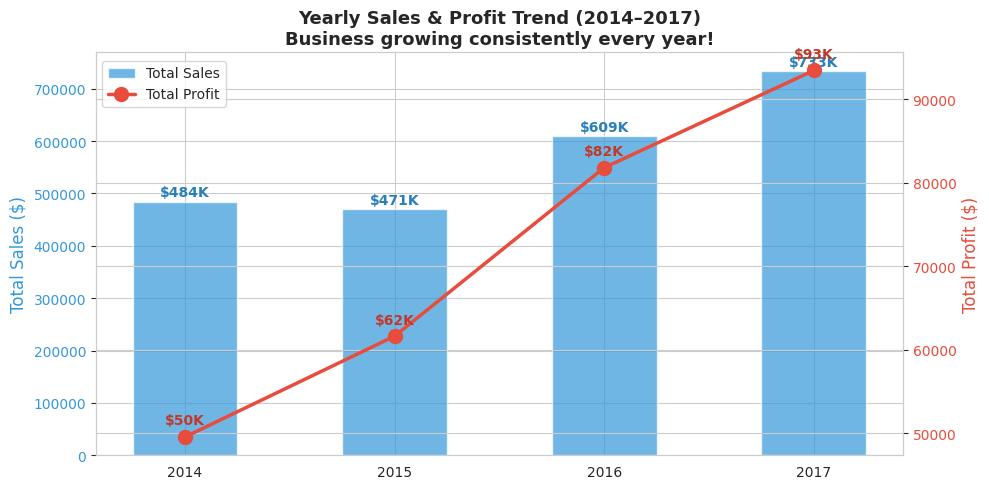

In [ ]:
yearly = pd.read_sql_query("""
    SELECT SUBSTR("Order Date", -4) AS Year,
           ROUND(SUM(Sales), 2)     AS Total_Sales,
           ROUND(SUM(Profit), 2)    AS Total_Profit
    FROM orders GROUP BY Year ORDER BY Year
""", conn)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(yearly['Year'], yearly['Total_Sales'],
        color='#3498db', alpha=0.7, label='Total Sales', width=0.5)
ax1.set_ylabel('Total Sales ($)', color='#3498db', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(yearly['Year'], yearly['Total_Profit'],
         color='#e74c3c', marker='o', linewidth=2.5,
         markersize=10, label='Total Profit')
ax2.set_ylabel('Total Profit ($)', color='#e74c3c', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Add value labels
for i, (s, p) in enumerate(zip(yearly['Total_Sales'], yearly['Total_Profit'])):
    ax1.text(i, s + 10000, f'${s/1000:.0f}K', ha='center', fontsize=10, color='#2980b9', fontweight='bold')
    ax2.text(i, p + 1500, f'${p/1000:.0f}K', ha='center', fontsize=10, color='#c0392b', fontweight='bold')

plt.title('Yearly Sales & Profit Trend (2014–2017)\nBusiness growing consistently every year!',
          fontsize=13, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()

### Chart 2 — Discount Impact on Profit

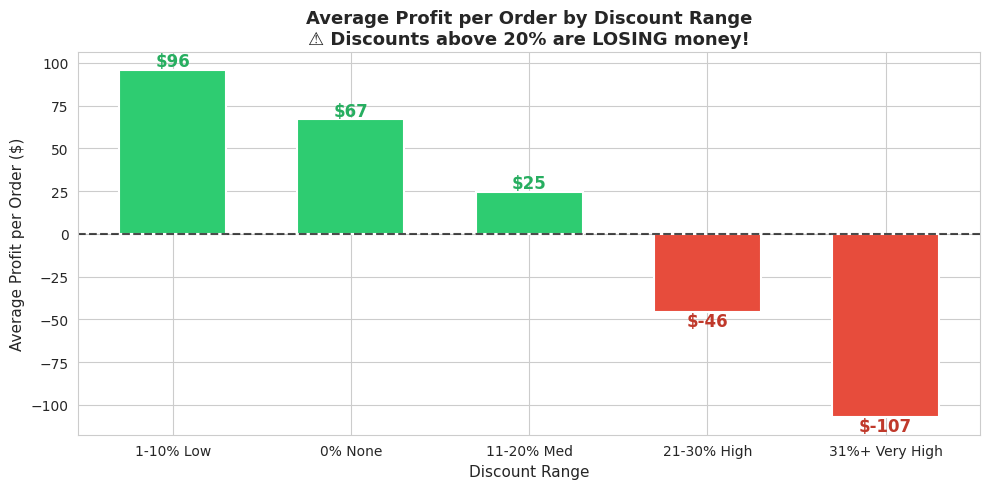

In [ ]:
discount_data = pd.read_sql_query("""
    SELECT
        CASE
            WHEN Discount = 0     THEN '0% None'
            WHEN Discount <= 0.10 THEN '1-10% Low'
            WHEN Discount <= 0.20 THEN '11-20% Med'
            WHEN Discount <= 0.30 THEN '21-30% High'
            ELSE '31%+ Very High'
        END AS Discount_Range,
        ROUND(AVG(Profit), 2) AS Avg_Profit
    FROM orders
    GROUP BY Discount_Range
    ORDER BY Avg_Profit DESC
""", conn)

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in discount_data['Avg_Profit']]

plt.figure(figsize=(10, 5))
bars = plt.bar(discount_data['Discount_Range'],
               discount_data['Avg_Profit'],
               color=colors, edgecolor='white', linewidth=1.5, width=0.6)
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
plt.title('Average Profit per Order by Discount Range\n'
          '⚠️ Discounts above 20% are LOSING money!',
          fontsize=13, fontweight='bold')
plt.xlabel('Discount Range', fontsize=11)
plt.ylabel('Average Profit per Order ($)', fontsize=11)
for bar, val in zip(bars, discount_data['Avg_Profit']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (2 if val > 0 else -8),
             f'${val:.0f}', ha='center',
             fontweight='bold', fontsize=12,
             color='#27ae60' if val > 0 else '#c0392b')
plt.tight_layout()
plt.show()

### Chart 3 — Sales by Region and Category

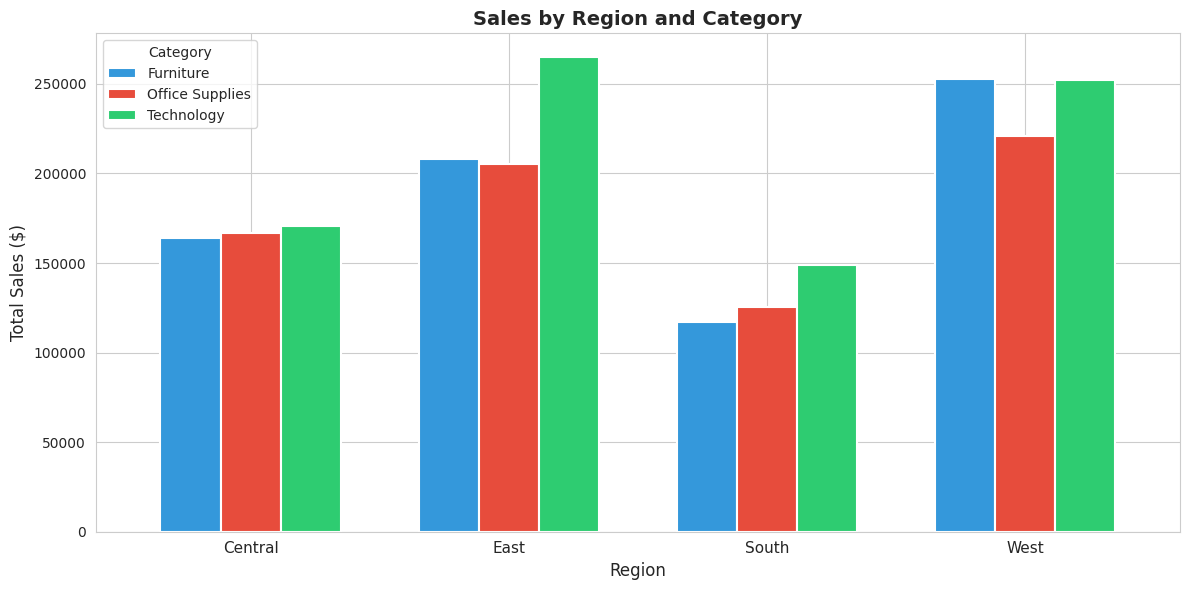

In [ ]:
region_cat = pd.read_sql_query("""
    SELECT Region, Category,
           ROUND(SUM(Sales), 2) AS Total_Sales
    FROM orders
    GROUP BY Region, Category
    ORDER BY Region, Total_Sales DESC
""", conn)

pivot = region_cat.pivot(index='Region', columns='Category', values='Total_Sales')

ax = pivot.plot(kind='bar', figsize=(12, 6),
           color=['#3498db', '#e74c3c', '#2ecc71'],
           edgecolor='white', linewidth=1.5, width=0.7)
plt.title('Sales by Region and Category', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Category', fontsize=10)
plt.tight_layout()
plt.show()

### Chart 4 — Profit by Sub-Category

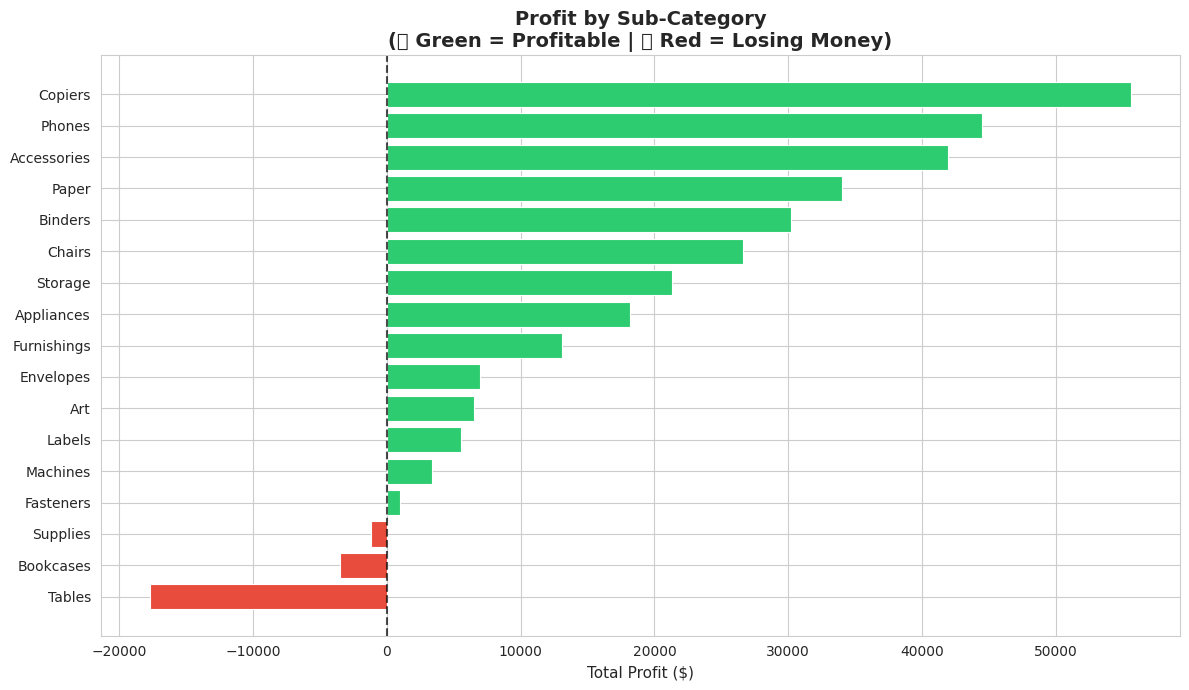

In [ ]:
subcat = pd.read_sql_query("""
    SELECT "Sub-Category",
           ROUND(SUM(Profit), 2) AS Total_Profit
    FROM orders
    GROUP BY "Sub-Category"
    ORDER BY Total_Profit DESC
""", conn)

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in subcat['Total_Profit']]

plt.figure(figsize=(12, 7))
bars = plt.barh(subcat['Sub-Category'],
                subcat['Total_Profit'],
                color=colors, edgecolor='white', linewidth=0.8)
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
plt.title('Profit by Sub-Category\n(🟢 Green = Profitable | 🔴 Red = Losing Money)',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)', fontsize=11)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## ✅ Section 4: Key Findings & Business Recommendations

### 🔍 Summary of Findings

| # | Finding | Impact |
|---|---------|--------|
| 1 | Business grew 51% in revenue (2014–2017) | Positive trend |
| 2 | **West region leads** with highest profit margins (14.9%) | Focus here |
| 3 | **Tables losing -$17,725** despite $207K sales | Critical issue |
| 4 | **5 top states are losing money** (Texas, Ohio etc.) | Discount problem |
| 5 | **Discounts above 20% cause losses** | Policy change needed |
| 6 | Sean Miller — top customer but -$1,981 loss | Pricing review |
| 7 | Technology = best category (37% margins on Copiers) | Prioritize |
| 8 | Furniture = worst category (only 2.5% overall margin) | Fix urgently |

---

### 🎯 Business Recommendations

**1. 🚨 Implement discount cap policy**
> Cap all discounts at maximum **20%**. Orders above 20% discount lose an average of $46 per order. This single change could recover **$125,000+ in annual losses**.

**2. 📦 Review Tables and Bookcases pricing**
> Tables alone lost **7,725** on 07K in sales — a -8.6% margin. Bookcases lost **,473**. Together these two sub-categories erased ~1K in profit. Removing the average 26% discount on Tables and restoring to a 5% margin would generate ~0,350 in additional profit annually.

**3. 🗺️ Audit Texas, Ohio and Pennsylvania**
> Texas generated 70K in sales but only **3,827 in profit**. Ohio: 8K sales, **3,600 profit**. Pennsylvania: 16K sales, **5,100 profit**. Combined loss from these 3 states: **~2,500**. A regional discount approval policy targeting these states could realistically recover 60–70% of these losses.

**4. 💼 Prioritize Technology products**
> Technology generates **45K profit on 36K sales (17.4% margin)** vs Furniture's 8K on 42K (2.5% margin). Shifting 10% of Furniture marketing budget to Technology could conservatively add **,000–2,000 in incremental profit** based on category margin differentials.

**5. 👤 Review unprofitable top customers**
> Sean Miller spent 5K but generated **-,981 in loss**. Becky Martin: 0.5K revenue, **-,879 loss**. Combined: 5.5K revenue producing net losses. Renegotiating their discount structure to match the company average (15.6%) would convert these accounts to profitable ones worth an estimated **+,500–,000 annually**.

---

### 💼 SQL Skills Demonstrated

| SQL Skill | Query Used |
|-----------|-----------|
| Basic SELECT, WHERE, FROM | All queries |
| Aggregate functions (SUM, COUNT, AVG) | Q1–Q11 |
| GROUP BY, ORDER BY, HAVING | Q2–Q11 |
| CASE WHEN (conditional logic) | Q10 |
| SUBSTR (string functions) | Q7 |
| WITH clause (CTE) | Q12 |
| Window functions RANK() OVER (PARTITION BY) | Q12 |
| Subquery / nested queries | Q12 |

---

